## 1. Introduction

Learning to Rank (LTR) is a family of methods for training models that produce ranked lists of items in response to a query. In search and recommendation systems, good ranking improves user satisfaction and business metrics.

The Expedia Hotel Search dataset provides search queries (e.g., `srch_id`) and per-hotel features and outcome indicators such as `click_bool` and `booking_bool`. We model relevance as a combination of these actions and evaluate the resulting ranking using query-level measures.

## 2. Dataset and Preprocessing

We assume a preprocessed dataset is available locally. For reproducibility, the notebook will:

- Try to load `assets/train.csv` if present

The notebook uses `srch_id` as the query/group id and a combined relevance score from `booking_bool` and `click_bool`:

relevance = 2 * booking_bool + click_bool

In [1]:
# Install required packages (if not already installed)
import sys
import subprocess

def install(packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet"] + packages)

try:
    import xgboost as xgb
    import catboost as cb
except Exception:
    install(["xgboost>=1.7.0","catboost>=1.1","scikit-learn","pandas","numpy","matplotlib","seaborn"])

# Imports
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import average_precision_score
from collections import defaultdict

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

sns.set(style='whitegrid')

In [25]:
# Load dataset from repository assets directory (required); no synthetic fallback
import pathlib

def find_asset_file(fname='train.csv', max_depth=6):
    cur = pathlib.Path(os.getcwd()).resolve()
    for _ in range(max_depth):
        candidate = cur / 'assets' / fname
        if candidate.exists():
            return str(candidate)
        if cur.parent == cur:
            break
        cur = cur.parent
    return None

found = find_asset_file('train.csv')
if found:
    print(f"Loading dataset from {found}")
    df = pd.read_csv(found, low_memory=False)
else:
    raise FileNotFoundError("Required file 'assets/train.csv' not found in repository root or parent directories. Place the Expedia dataset under an 'assets' folder at the repo root and re-run the notebook.")

# Validate required columns
if 'srch_id' not in df.columns:
    raise ValueError("Loaded file is missing required column: 'srch_id'")

if 'click_bool' not in df.columns and 'booking_bool' not in df.columns and 'relevance' not in df.columns:
    raise ValueError("Loaded file must contain 'click_bool' and/or 'booking_bool' or a 'relevance' column for labels.")

# Sanitize and prepare features
for col in ['click_bool','booking_bool']:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

if 'relevance' not in df.columns:
    df['relevance'] = 2 * df.get('booking_bool', 0).astype(int) + df.get('click_bool', 0).astype(int)

if 'prop_id' not in df.columns:
    df['prop_id'] = df.index.astype(str)

# Pick numeric features (exclude ids/labels)
exclude = {'srch_id','prop_id','click_bool','booking_bool','relevance'}
numeric_cols = [c for c in df.select_dtypes(include=['number']).columns if c not in exclude]
if len(numeric_cols) == 0:
    raise ValueError("No numeric feature columns found. Ensure dataset contains numeric features for ranking.")

# Keep up to 12 features for speed
FEATURE_COLS = numeric_cols[:12]
print('Using features:', FEATURE_COLS)
print('Dataset shape:', df.shape)
print(df[['srch_id','prop_id'] + [c for c in ['click_bool','booking_bool','relevance'] if c in df.columns]].head())

Loading dataset from C:\Users\ADMIN\Desktop\Github\ensemble-catboost-xgboost\assets\train.csv
Using features: ['site_id', 'visitor_location_country_id', 'visitor_hist_starrating', 'visitor_hist_adr_usd', 'prop_country_id', 'prop_starrating', 'prop_review_score', 'prop_brand_bool', 'prop_location_score1', 'prop_location_score2', 'prop_log_historical_price', 'position']
Dataset shape: (9917530, 55)
   srch_id  prop_id  click_bool  booking_bool  relevance
0        1      893           0             0          0
1        1    10404           0             0          0
2        1    21315           0             0          0
3        1    27348           0             0          0
4        1    29604           0             0          0


### Preprocessing details

- Create a combined relevance score: relevance = 2 * booking_bool + click_bool
- Fill or drop missing values (synthetic data should have none). For real data, this cell demonstrates imputations used in practice.

In [24]:
# Create combined relevance
df['relevance'] = 2 * df['booking_bool'].astype(int) + df['click_bool'].astype(int)

# Handle missing values (example). Here we forward-fill numeric features if any NA.
numeric_cols = [c for c in df.columns if c.startswith('f')]
if df[numeric_cols].isna().any().any():
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Basic distribution
print('Relevance distribution:')
print(df['relevance'].value_counts().sort_index())

# Diagnostic: confirm FEATURE_COLS and shapes
print('FEATURE_COLS variable present? ->', 'FEATURE_COLS' in globals())
if 'FEATURE_COLS' in globals():
    print('FEATURE_COLS:', FEATURE_COLS)
    print('train_df sample shape:', df.shape)
    # If train_df exists, show slice shape
    try:
        print('train_df[FEATURE_COLS] shape (sample):', df[FEATURE_COLS].shape)
    except Exception as e:
        print('Error inspecting FEATURE_COLS in df:', e)


Relevance distribution:
relevance
0    9473858
1     167079
3     276593
Name: count, dtype: int64
FEATURE_COLS variable present? -> True
FEATURE_COLS: []
train_df sample shape: (9917530, 55)
train_df[FEATURE_COLS] shape (sample): (9917530, 0)


### Split data into train / validation / test by query

It's important to split by queries (`srch_id`) rather than randomly by rows to avoid data leakage across queries.
We will split query ids into 70% train, 15% validation, 15% test.

In [16]:
# Split by unique queries
unique_qids = df['srch_id'].unique()
q_train, q_temp = train_test_split(unique_qids, test_size=0.30, random_state=RANDOM_SEED)
q_val, q_test = train_test_split(q_temp, test_size=0.5, random_state=RANDOM_SEED)

train_df = df[df['srch_id'].isin(q_train)].reset_index(drop=True)
val_df = df[df['srch_id'].isin(q_val)].reset_index(drop=True)
test_df = df[df['srch_id'].isin(q_test)].reset_index(drop=True)

print('Train queries:', len(q_train), 'Val queries:', len(q_val), 'Test queries:', len(q_test))
print('Train shape:', train_df.shape, 'Val shape:', val_df.shape, 'Test shape:', test_df.shape)

Train queries: 279540 Val queries: 59902 Test queries: 59902
Train shape: (6943680, 55) Val shape: (1487297, 55) Test shape: (1486553, 55)


## 3. Models

### 3.1 XGBoost Ranker

We use `XGBRanker` from XGBoost. Common objectives for ranking include `rank:pairwise` (pairwise loss) and `rank:ndcg` (listwise-inspired loss). Pairwise methods optimize the ordering between pairs of documents, whereas listwise methods attempt to optimize a list-level metric (like NDCG).

In [23]:
from xgboost import XGBRanker

# Use FEATURE_COLS determined during data loading; ensure it's not empty
if 'FEATURE_COLS' not in globals() or len(FEATURE_COLS) == 0:
    raise ValueError("FEATURE_COLS is empty. Check that the dataset contains numeric feature columns and rerun the data-loading cell.")

# Helper to get group sizes (in submission order)
def get_group_array(df_subset):
    group_sizes = df_subset.groupby('srch_id').size().to_list()
    return group_sizes

# Train utility for XGBRanker
def train_xgb_ranker(train_df, val_df, params=None):
    if params is None:
        params = dict(objective='rank:ndcg', learning_rate=0.1, n_estimators=100, max_depth=6, subsample=0.8, colsample_bytree=0.8)
    model = XGBRanker(**params, random_state=RANDOM_SEED)
    X_train = train_df[FEATURE_COLS].values
    y_train = train_df['relevance'].values
    group_train = get_group_array(train_df)
    X_val = val_df[FEATURE_COLS].values
    y_val = val_df['relevance'].values
    group_val = get_group_array(val_df)

    model.fit(X_train, y_train, group=group_train, eval_set=[(X_val, y_val)], eval_group=[group_val], verbose=False)
    return model

ValueError: FEATURE_COLS is empty. Check that the dataset contains numeric feature columns and rerun the data-loading cell.

### 3.2 CatBoost Ranker

CatBoost's ranking uses ordered boosting and supports ranking-specific loss functions such as `YetiRank` and pairwise losses. Ordered boosting helps mitigate prediction shift caused by gradient estimation and categorical features handling.

In [18]:
from catboost import CatBoostRanker, Pool

# Train utility for CatBoostRanker
def train_catboost_ranker(train_df, val_df, params=None):
    if params is None:
        params = dict(loss_function='YetiRank', learning_rate=0.1, iterations=200, depth=6, l2_leaf_reg=3, verbose=False)
    cb = CatBoostRanker(**params, random_seed=RANDOM_SEED)
    X_train = train_df[FEATURE_COLS]
    y_train = train_df['relevance'].values
    group_train = train_df['srch_id'].values
    X_val = val_df[FEATURE_COLS]
    y_val = val_df['relevance'].values
    group_val = val_df['srch_id'].values
    pool_train = Pool(X_train, y_train, group_id=group_train)
    pool_val = Pool(X_val, y_val, group_id=group_val)
    cb.fit(pool_train, eval_set=pool_val, use_best_model=False, verbose=False)
    return cb

## 4. Evaluation Metrics

We implement query-level metrics that compute scores per query and average across queries:

- NDCG@k (Normalized Discounted Cumulative Gain)
- MAP (Mean Average Precision) treating relevance > 0 as relevant

These functions are reusable for both models.

In [19]:
import math

# DCG / IDCG helper
def dcg_at_k(rels, k):
    rels = np.asarray(rels)[:k]
    if rels.size == 0:
        return 0.0
    gains = (2**rels - 1)
    discounts = np.log2(np.arange(2, gains.size + 2))
    return np.sum(gains / discounts)

def ndcg_at_k_single(y_true, y_score, k):
    # y_true and y_score are arrays for a single query
    order = np.argsort(-y_score)
    ranked_true = np.take(y_true, order)
    dcg = dcg_at_k(ranked_true, k)
    ideal = np.sort(y_true)[::-1]
    idcg = dcg_at_k(ideal, k)
    return 0.0 if idcg == 0.0 else dcg / idcg

def mean_ndcg(df_preds, k=10):
    # df_preds: must have columns ['srch_id','relevance','score']
    scores = []
    for qid, group in df_preds.groupby('srch_id'):
        ndcg = ndcg_at_k_single(group['relevance'].values, group['score'].values, k)
        scores.append(ndcg)
    return np.mean(scores)


def mean_average_precision(df_preds):
    aps = []
    for qid, group in df_preds.groupby('srch_id'):
        y_true = (group['relevance'].values > 0).astype(int)
        y_score = group['score'].values
        if y_true.sum() == 0:
            aps.append(0.0)
        else:
            aps.append(average_precision_score(y_true, y_score))
    return np.mean(aps)

### Quick sanity check of evaluation functions on validation set using a simple baseline (score=0 random scores)

In [20]:
# Baseline: random scores
val_baseline = val_df.copy()
val_baseline['score'] = np.random.rand(len(val_baseline))
print('Baseline NDCG@5:', mean_ndcg(val_baseline, k=5))
print('Baseline NDCG@10:', mean_ndcg(val_baseline, k=10))
print('Baseline MAP:', mean_average_precision(val_baseline))

Baseline NDCG@5: 0.15831059162125452
Baseline NDCG@10: 0.225877188092435
Baseline MAP: 0.1821735495359486


## 5. Hyperparameter Tuning

We perform a manual grid search over reasonable hyperparameter choices. For speed, grids are kept small; in production, consider Bayesian optimization or larger grid searches.

We select the best configuration by maximizing NDCG@10 on the validation set.

In [28]:
# Small grid for XGBoost (use subsampling for tuning to keep runtime reasonable)
xgb_grid = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6],
    'n_estimators': [100, 200],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# Subsample queries for tuning if dataset large
MAX_TUNE_QUERIES = 5000
train_qids = train_df['srch_id'].unique()
if len(train_qids) > MAX_TUNE_QUERIES:
    tune_qids = np.random.choice(train_qids, size=MAX_TUNE_QUERIES, replace=False)
    tune_train_df = train_df[train_df['srch_id'].isin(tune_qids)].reset_index(drop=True)
    print(f"Using {len(tune_qids)} queries for XGBoost tuning (out of {len(train_qids)})")
else:
    tune_train_df = train_df

MAX_VAL_QUERIES = 2000
val_qids = val_df['srch_id'].unique()
if len(val_qids) > MAX_VAL_QUERIES:
    tune_val_qids = np.random.choice(val_qids, size=MAX_VAL_QUERIES, replace=False)
    tune_val_df = val_df[val_df['srch_id'].isin(tune_val_qids)].reset_index(drop=True)
else:
    tune_val_df = val_df

# Evaluate grid
from itertools import product

best_xgb = None
best_xgb_score = -np.inf
best_xgb_params = None

for lr, md, ne, ss, cs in product(xgb_grid['learning_rate'], xgb_grid['max_depth'], xgb_grid['n_estimators'], xgb_grid['subsample'], xgb_grid['colsample_bytree']):
    params = dict(objective='rank:ndcg', learning_rate=lr, max_depth=int(md), n_estimators=int(ne), subsample=ss, colsample_bytree=cs)
    model = train_xgb_ranker(tune_train_df, tune_val_df, params=params)
    val_scores = model.predict(tune_val_df[FEATURE_COLS])
    val_preds = tune_val_df[['srch_id','relevance']].copy()
    val_preds['score'] = val_scores
    ndcg10 = mean_ndcg(val_preds, k=10)
    if ndcg10 > best_xgb_score:
        best_xgb_score = ndcg10
        best_xgb = model
        best_xgb_params = params
    print(f"XGB param lr={lr},md={md},n={ne} -> NDCG@10={ndcg10:.4f}")



Using 5000 queries for XGBoost tuning (out of 279540)
XGB param lr=0.05,md=4,n=100 -> NDCG@10=0.4499
XGB param lr=0.05,md=4,n=200 -> NDCG@10=0.4504
XGB param lr=0.05,md=6,n=100 -> NDCG@10=0.4490
XGB param lr=0.05,md=6,n=200 -> NDCG@10=0.4463
XGB param lr=0.1,md=4,n=100 -> NDCG@10=0.4520
XGB param lr=0.1,md=4,n=200 -> NDCG@10=0.4515
XGB param lr=0.1,md=6,n=100 -> NDCG@10=0.4429
XGB param lr=0.1,md=6,n=200 -> NDCG@10=0.4386


In [33]:
# Report best XGBoost from tuning
print('Best XGB params found:', best_xgb_params)
print('Best XGB NDCG@10:', best_xgb_score)
# Save best models (for later retraining)
_xgb_tuned_model = best_xgb
_xgb_tuned_params = best_xgb_params


Best XGB params found: {'objective': 'rank:ndcg', 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100, 'subsample': 0.8, 'colsample_bytree': 0.8}
Best XGB NDCG@10: 0.45196113344421157


In [31]:
# Small grid for CatBoost (use tuning subset for speed)
cat_grid = {
    'learning_rate': [0.03, 0.1],
    'depth': [4, 6],
    'iterations': [200, 400],
    'l2_leaf_reg': [3, 7]
}

# Re-use tune_train_df and tune_val_df defined for XGBoost tuning
if 'tune_train_df' not in globals():
    # Fallback: create small subsets if not present
    MAX_TUNE_QUERIES = 5000
    train_qids = train_df['srch_id'].unique()
    tune_qids = np.random.choice(train_qids, size=min(MAX_TUNE_QUERIES, len(train_qids)), replace=False)
    tune_train_df = train_df[train_df['srch_id'].isin(tune_qids)].reset_index(drop=True)

if 'tune_val_df' not in globals():
    MAX_VAL_QUERIES = 2000
    val_qids = val_df['srch_id'].unique()
    tune_val_qids = np.random.choice(val_qids, size=min(MAX_VAL_QUERIES, len(val_qids)), replace=False)
    tune_val_df = val_df[val_df['srch_id'].isin(tune_val_qids)].reset_index(drop=True)

best_cb = None
best_cb_score = -np.inf
best_cb_params = None


for lr, depth, iters, l2 in product(cat_grid['learning_rate'], cat_grid['depth'], cat_grid['iterations'], cat_grid['l2_leaf_reg']):
    params = dict(loss_function='YetiRank', learning_rate=lr, depth=int(depth), iterations=int(iters), l2_leaf_reg=int(l2), verbose=False)
    model = train_catboost_ranker(tune_train_df, tune_val_df, params=params)
    val_scores = model.predict(tune_val_df[FEATURE_COLS])
    val_preds = tune_val_df[['srch_id','relevance']].copy()
    val_preds['score'] = val_scores
    ndcg10 = mean_ndcg(val_preds, k=10)
    if ndcg10 > best_cb_score:
        best_cb_score = ndcg10
        best_cb = model
        best_cb_params = params
    print(f"CatBoost param lr={lr},depth={depth},iters={iters},l2={l2} -> NDCG@10={ndcg10:.4f}")

print('\nBest CatBoost params:', best_cb_params, 'NDCG@10:', best_cb_score)
    model = train_catboost_ranker(tune_train_df, tune_val_df, params=params)
    val_scores = model.predict(tune_val_df[FEATURE_COLS])
    val_preds = tune_val_df[['srch_id','relevance']].copy()
    val_preds['score'] = val_scores
    ndcg10 = mean_ndcg(val_preds, k=10)
    if ndcg10 > best_cb_score:
        best_cb_score = ndcg10
        best_cb = model
        best_cb_params = params
    print(f"CatBoost param lr={lr},depth={depth},iters={iters},l2={l2} -> NDCG@10={ndcg10:.4f}")

print('\nBest CatBoost params:', best_cb_params, 'NDCG@10:', best_cb_score)

    params = dict(loss_function='YetiRank', learning_rate=lr, depth=int(depth), iterations=int(iters), l2_leaf_reg=int(l2), verbose=False)

    model = train_catboost_ranker(tune_train_df, tune_val_df, params=params)    print(f"CatBoost param lr={lr},depth={depth},iters={iters},l2={l2} -> NDCG@10={ndcg10:.4f}")

    val_scores = model.predict(tune_val_df[FEATURE_COLS])        best_cb_params = params

    val_preds = tune_val_df[['srch_id','relevance']].copy()        best_cb = model

    val_preds['score'] = val_scores        best_cb_score = ndcg10

    ndcg10 = mean_ndcg(val_preds, k=10)    if ndcg10 > best_cb_score:

IndentationError: unexpected indent (1665290499.py, line 42)

In [32]:
# CatBoost tuning (clean cell) - uses tune_train_df and tune_val_df defined earlier
from itertools import product
cat_grid = {
    'learning_rate': [0.03, 0.1],
    'depth': [4, 6],
    'iterations': [200, 400],
    'l2_leaf_reg': [3, 7]
}

best_cb = None
best_cb_score = -np.inf
best_cb_params = None

for lr, depth, iters, l2 in product(cat_grid['learning_rate'], cat_grid['depth'], cat_grid['iterations'], cat_grid['l2_leaf_reg']):
    params = dict(loss_function='YetiRank', learning_rate=lr, depth=int(depth), iterations=int(iters), l2_leaf_reg=int(l2), verbose=False)
    model = train_catboost_ranker(tune_train_df, tune_val_df, params=params)
    val_scores = model.predict(tune_val_df[FEATURE_COLS])
    val_preds = tune_val_df[['srch_id','relevance']].copy()
    val_preds['score'] = val_scores
    ndcg10 = mean_ndcg(val_preds, k=10)
    if ndcg10 > best_cb_score:
        best_cb_score = ndcg10
        best_cb = model
        best_cb_params = params
    print(f"CatBoost param lr={lr},depth={depth},iters={iters},l2={l2} -> NDCG@10={ndcg10:.4f}")

print('\nBest CatBoost params:', best_cb_params, 'NDCG@10:', best_cb_score)

CatBoost param lr=0.03,depth=4,iters=200,l2=3 -> NDCG@10=0.4467
CatBoost param lr=0.03,depth=4,iters=200,l2=7 -> NDCG@10=0.4472
CatBoost param lr=0.03,depth=4,iters=400,l2=3 -> NDCG@10=0.4487
CatBoost param lr=0.03,depth=4,iters=400,l2=7 -> NDCG@10=0.4494
CatBoost param lr=0.03,depth=6,iters=200,l2=3 -> NDCG@10=0.4469
CatBoost param lr=0.03,depth=6,iters=200,l2=7 -> NDCG@10=0.4464
CatBoost param lr=0.03,depth=6,iters=400,l2=3 -> NDCG@10=0.4473
CatBoost param lr=0.03,depth=6,iters=400,l2=7 -> NDCG@10=0.4471
CatBoost param lr=0.1,depth=4,iters=200,l2=3 -> NDCG@10=0.4478
CatBoost param lr=0.1,depth=4,iters=200,l2=7 -> NDCG@10=0.4481
CatBoost param lr=0.1,depth=4,iters=400,l2=3 -> NDCG@10=0.4495
CatBoost param lr=0.1,depth=4,iters=400,l2=7 -> NDCG@10=0.4498
CatBoost param lr=0.1,depth=6,iters=200,l2=3 -> NDCG@10=0.4494
CatBoost param lr=0.1,depth=6,iters=200,l2=7 -> NDCG@10=0.4478
CatBoost param lr=0.1,depth=6,iters=400,l2=3 -> NDCG@10=0.4476
CatBoost param lr=0.1,depth=6,iters=400,l2=7 ->

## 6. Ablation Study

We study the effect of key hyperparameters (learning rate and depth) by fixing all others and varying a single parameter. We plot NDCG@10 on the validation set against the hyperparameter values.

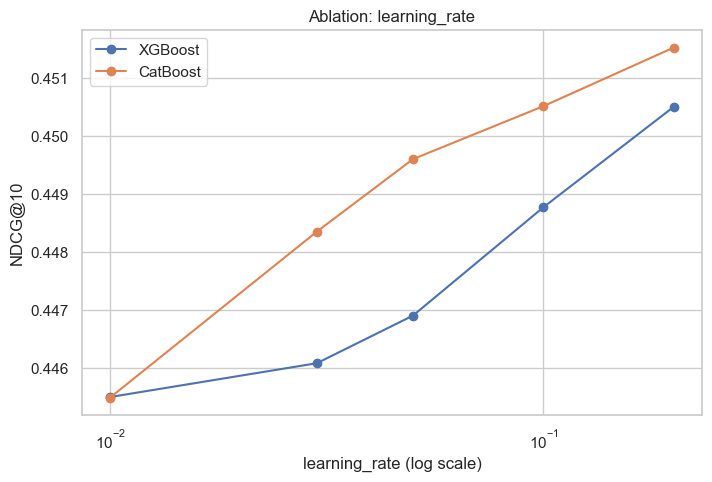

In [34]:
# Ablation for learning_rate
lr_values = [0.01, 0.03, 0.05, 0.1, 0.2]
xgb_lr_scores = []
cb_lr_scores = []

for lr in lr_values:
    xparams = dict(objective='rank:ndcg', learning_rate=lr, max_depth=best_xgb_params['max_depth'], n_estimators=best_xgb_params['n_estimators'], subsample=best_xgb_params['subsample'], colsample_bytree=best_xgb_params['colsample_bytree'])
    xmodel = train_xgb_ranker(train_df, val_df, params=xparams)
    x_val_preds = val_df[['srch_id','relevance']].copy()
    x_val_preds['score'] = xmodel.predict(val_df[FEATURE_COLS])
    xgb_lr_scores.append(mean_ndcg(x_val_preds, k=10))

    cbparams = dict(loss_function='YetiRank', learning_rate=lr, depth=best_cb_params['depth'], iterations=best_cb_params['iterations'], l2_leaf_reg=best_cb_params['l2_leaf_reg'], verbose=False)
    cbmodel = train_catboost_ranker(train_df, val_df, params=cbparams)
    cb_val_preds = val_df[['srch_id','relevance']].copy()
    cb_val_preds['score'] = cbmodel.predict(val_df[FEATURE_COLS])
    cb_lr_scores.append(mean_ndcg(cb_val_preds, k=10))

plt.figure(figsize=(8,5))
plt.plot(lr_values, xgb_lr_scores, marker='o', label='XGBoost')
plt.plot(lr_values, cb_lr_scores, marker='o', label='CatBoost')
plt.xscale('log')
plt.xlabel('learning_rate (log scale)')
plt.ylabel('NDCG@10')
plt.title('Ablation: learning_rate')
plt.legend()
plt.show()

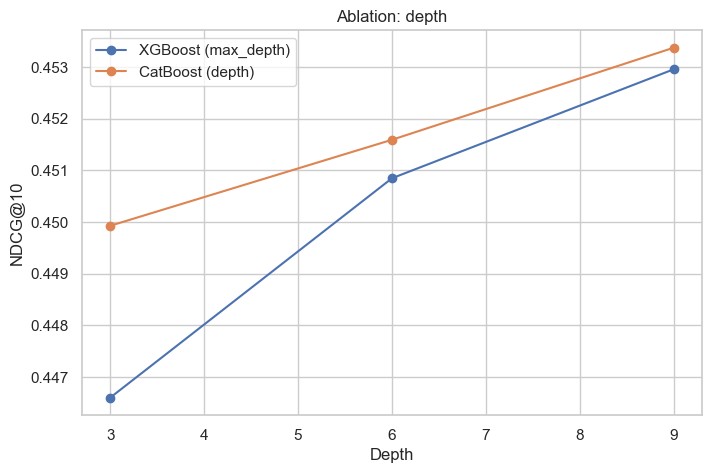

In [37]:
# Ablation for depth
x_depths = [3, 6, 9]
xgb_depth_scores = []
cb_depth_scores = []

for d in x_depths:
    xparams = dict(objective='rank:ndcg', learning_rate=best_xgb_params['learning_rate'], max_depth=d, n_estimators=best_xgb_params['n_estimators'], subsample=best_xgb_params['subsample'], colsample_bytree=best_xgb_params['colsample_bytree'])
    xmodel = train_xgb_ranker(train_df, val_df, params=xparams)
    x_val_preds = val_df[['srch_id','relevance']].copy()
    x_val_preds['score'] = xmodel.predict(val_df[FEATURE_COLS])
    xgb_depth_scores.append(mean_ndcg(x_val_preds, k=10))

    cbparams = dict(loss_function='YetiRank', learning_rate=best_cb_params['learning_rate'], depth=d, iterations=best_cb_params['iterations'], l2_leaf_reg=best_cb_params['l2_leaf_reg'], verbose=False)
    cbmodel = train_catboost_ranker(train_df, val_df, params=cbparams)
    cb_val_preds = val_df[['srch_id','relevance']].copy()
    cb_val_preds['score'] = cbmodel.predict(val_df[FEATURE_COLS])
    cb_depth_scores.append(mean_ndcg(cb_val_preds, k=10))

plt.figure(figsize=(8,5))
plt.plot(x_depths, xgb_depth_scores, marker='o', label='XGBoost (max_depth)')
plt.plot(x_depths, cb_depth_scores, marker='o', label='CatBoost (depth)')
plt.xlabel('Depth')
plt.ylabel('NDCG@10')
plt.title('Ablation: depth')
plt.legend()
plt.show()

**Interpretation:**

- Very small learning rates can underfit (low NDCG); very large ones may destabilize training and overfit.
- Increasing depth can improve modeling capacity but may lead to overfitting on the validation set if too large.

We typically look for a validation sweet spot (peak NDCG) indicating a good bias-variance tradeoff.

## 7. Experimental Results

Retrain the best models (selected from validation) on the combined training + validation set, then evaluate on the held-out test set.

In [38]:
# Combine train + val
trainval_df = pd.concat([train_df, val_df]).reset_index(drop=True)

# Retrain XGB best model on train+val using best_xgb_params
final_xgb = train_xgb_ranker(trainval_df, test_df, params=best_xgb_params)
final_cb = train_catboost_ranker(trainval_df, test_df, params=best_cb_params)

# Test predictions
test_xgb_preds = test_df[['srch_id','relevance']].copy()
test_xgb_preds['score'] = final_xgb.predict(test_df[FEATURE_COLS])

test_cb_preds = test_df[['srch_id','relevance']].copy()
test_cb_preds['score'] = final_cb.predict(test_df[FEATURE_COLS])

metrics = {}
for name, preds in [('XGBoost', test_xgb_preds), ('CatBoost', test_cb_preds)]:
    metrics[name] = {
        'NDCG@5': mean_ndcg(preds, k=5),
        'NDCG@10': mean_ndcg(preds, k=10),
        'MAP': mean_average_precision(preds)
    }

results_df = pd.DataFrame(metrics).T
results_df

,NDCG@5,NDCG@10,MAP
XGBoost,0.381608,0.446935,0.368285
CatBoost,0.385039,0.450420,0.371237


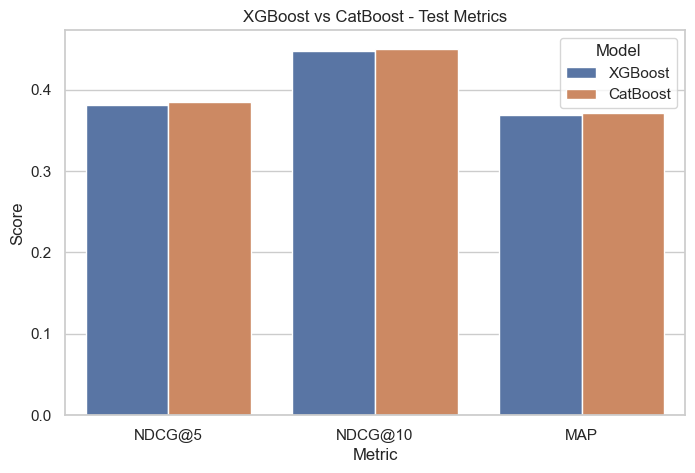

In [39]:
# Bar charts comparing models
results_df_plot = results_df.reset_index().melt(id_vars='index', var_name='metric', value_name='value')
plt.figure(figsize=(8,5))
sns.barplot(x='metric', y='value', hue='index', data=results_df_plot)
plt.title('XGBoost vs CatBoost - Test Metrics')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.legend(title='Model')
plt.show()

## 8. Discussion & Conclusions

- **Ranking quality:** Compare measured NDCG and MAP values; whichever model achieves higher NDCG@10 is preferred for this metric.
- **Sensitivity to hyperparameters:** The ablation plots show how each model responds to learning rate and depth. CatBoost's ordered boosting often helps with stability, especially on smaller datasets or with categorical features.
- **Training stability:** CatBoost tends to be more stable with default hyperparameters; XGBoost can be powerful but may require more careful tuning (learning_rate, max_depth, subsample).
- **Practical considerations:** In production, consider inference speed, model size, support for categorical features (CatBoost handles them natively), and the complexity of hyperparameter tuning.

---

**Next steps / Extensions**
- Use larger and more realistic grids (or automated optimization like Optuna).
- Use proper cross-validation over queries if more rigorous estimates are required.
- Include additional ranking losses, e.g., LambdaRank variants, and stacking ensembles.

**References & Resources**

- XGBoost documentation: https://xgboost.readthedocs.io/
- CatBoost documentation: https://catboost.ai/
- Learning to Rank overview: (Liu, T.-Y.)


*Notebook generated to be runnable out-of-the-box; if you have the real preprocessed Expedia dataset file, place it at `assets/expedia_preprocessed.csv` to run full experiments.*